In [1]:
!pip install pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,6)

In [3]:
traditional = pd.read_csv("/kaggle/input/notebooks/jigishadas/loc-and-cyclomatic-complexity/traditional_metrics.csv")
ssi = pd.read_csv("/kaggle/input/notebooks/jigishadas/ssi-creation/dataset_with_ssi.csv")

print("Traditional Metrics Shape :", traditional.shape)
print("SSI Dataset Shape :", ssi.shape)

Traditional Metrics Shape : (2000, 5)
SSI Dataset Shape : (2000, 36)


In [4]:
print("Traditional Columns:")
print(traditional.columns.tolist())

print()

print("SSI Columns:")
print(ssi.columns.tolist())

Traditional Columns:
['language', 'repository_name', 'func_name', 'LOC', 'Cyclomatic_Complexity']

SSI Columns:
['function_count', 'parameter_count', 'variable_count', 'declaration_count', 'if_count', 'for_count', 'while_count', 'switch_count', 'return_count', 'call_count', 'argument_count', 'assignment_count', 'binary_expression_count', 'identifier_count', 'block_count', 'expression_count', 'literal_count', 'ast_nodes', 'leaf_nodes', 'internal_nodes', 'max_depth', 'leaf_ratio', 'internal_ratio', 'branch_density', 'call_density', 'identifier_density', 'expression_density', 'variable_density', 'statement_density', 'nesting_factor', 'cyclomatic_estimate', 'avg_parameters', 'language', 'repository', 'function', 'SSI']


In [5]:
merged = pd.concat(
    [
        traditional,
        ssi.drop(columns=["SSI"], errors="ignore")
    ],
    axis=1
)

merged["SSI"] = ssi["SSI"]

In [6]:
merged.to_csv("unified_metrics.csv", index=False)

print(merged.head())

print("\nShape :", merged.shape)

   language               repository_name  \
0      java             molgenis/molgenis   
1      java               belaban/JGroups   
2      java  googleads/googleads-java-lib   
3      java      Azure/azure-sdk-for-java   
4      java      Azure/azure-sdk-for-java   

                                           func_name  LOC  \
0                                        L1Cache.put   10   
1                                  RequestTable.size    9   
2          DownloadCriteriaReportWithAwql.runExample   43   
3             NetworkInterfacesInner.updateTagsAsync    3   
4  BlobContainersInner.extendImmutabilityPolicyWi...   34   

   Cyclomatic_Complexity  function_count  parameter_count  variable_count  \
0                      2               1                2               2   
1                      4               1                0               7   
2                      3               1                3               8   
3                      1               1              

In [7]:
metrics = [
    "LOC",
    "Cyclomatic_Complexity",
    "ast_nodes",
    "max_depth",
    "SSI"
]

In [8]:
summary = merged[metrics].describe()

print(summary)

summary.to_csv("summary_statistics.csv")

               LOC  Cyclomatic_Complexity   ast_nodes    max_depth  \
count  2000.000000            2000.000000  2000.00000  2000.000000   
mean     19.884000               4.845000   191.69350    12.000500   
std      26.821097               6.581081   260.98436     4.444815   
min       3.000000               1.000000    33.00000     6.000000   
25%       7.000000               1.750000    69.00000     9.000000   
50%      12.000000               3.000000   115.00000    11.000000   
75%      22.000000               5.000000   209.25000    14.000000   
max     340.000000              79.000000  3538.00000    48.000000   

                SSI  
count  2.000000e+03  
mean   7.105427e-17  
std    3.482929e+00  
min   -2.916540e+00  
25%   -1.847858e+00  
50%   -9.652726e-01  
75%    5.402031e-01  
max    4.772197e+01  


In [9]:
corr = merged[metrics].corr(method="pearson")

print(corr)

corr.to_csv("correlation_matrix.csv")

                            LOC  Cyclomatic_Complexity  ast_nodes  max_depth  \
LOC                    1.000000               0.846392   0.915776   0.550262   
Cyclomatic_Complexity  0.846392               1.000000   0.797822   0.554504   
ast_nodes              0.915776               0.797822   1.000000   0.574693   
max_depth              0.550262               0.554504   0.574693   1.000000   
SSI                    0.928380               0.858566   0.964599   0.625164   

                            SSI  
LOC                    0.928380  
Cyclomatic_Complexity  0.858566  
ast_nodes              0.964599  
max_depth              0.625164  
SSI                    1.000000  


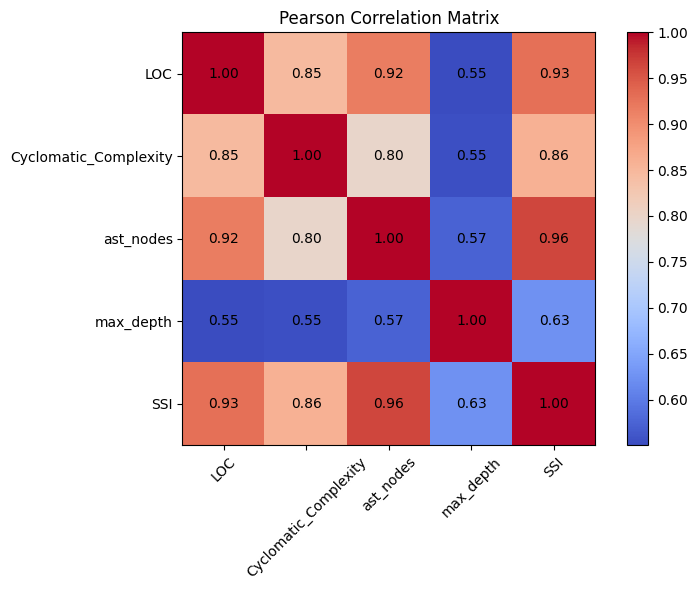

In [10]:
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(metrics)), metrics, rotation=45)
plt.yticks(range(len(metrics)), metrics)

for i in range(len(metrics)):
    for j in range(len(metrics)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Pearson Correlation Matrix")

plt.tight_layout()

plt.show()

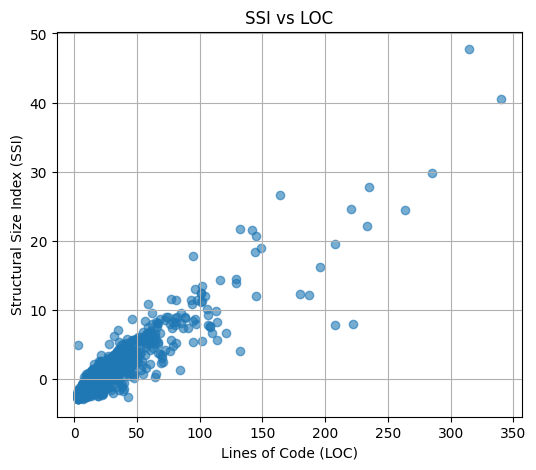

In [11]:
plt.figure(figsize=(6,5))

plt.scatter(
    merged["LOC"],
    merged["SSI"],
    alpha=0.6
)

plt.xlabel("Lines of Code (LOC)")
plt.ylabel("Structural Size Index (SSI)")
plt.title("SSI vs LOC")

plt.grid(True)

plt.show()

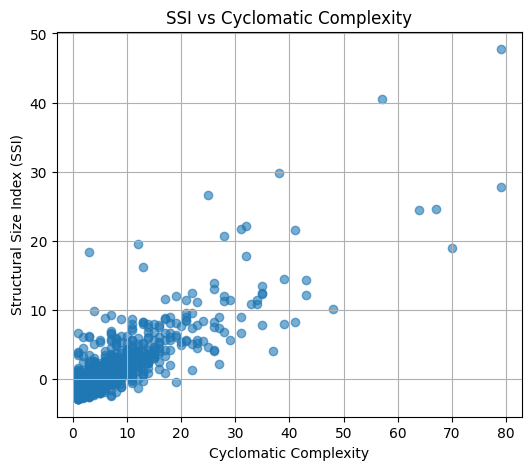

In [12]:
plt.figure(figsize=(6,5))

plt.scatter(
    merged["Cyclomatic_Complexity"],
    merged["SSI"],
    alpha=0.6
)

plt.xlabel("Cyclomatic Complexity")
plt.ylabel("Structural Size Index (SSI)")

plt.title("SSI vs Cyclomatic Complexity")

plt.grid(True)

plt.show()

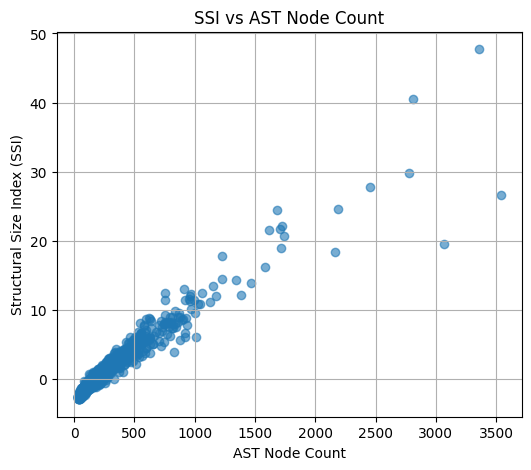

In [13]:
plt.figure(figsize=(6,5))

plt.scatter(
    merged["ast_nodes"],
    merged["SSI"],
    alpha=0.6
)

plt.xlabel("AST Node Count")
plt.ylabel("Structural Size Index (SSI)")

plt.title("SSI vs AST Node Count")

plt.grid(True)

plt.show()

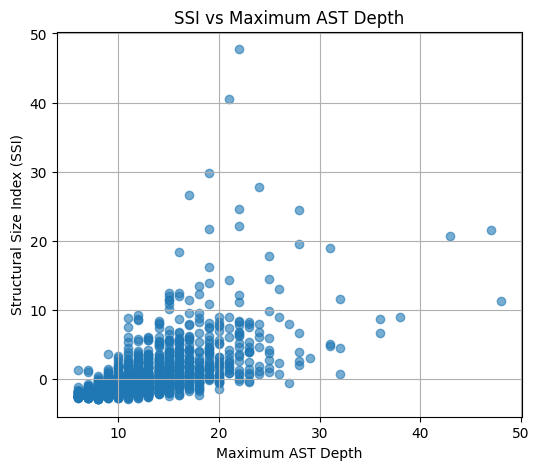

In [14]:
plt.figure(figsize=(6,5))

plt.scatter(
    merged["max_depth"],
    merged["SSI"],
    alpha=0.6
)

plt.xlabel("Maximum AST Depth")
plt.ylabel("Structural Size Index (SSI)")

plt.title("SSI vs Maximum AST Depth")

plt.grid(True)

plt.show()